# Imports

In [1]:
import pandas as pd
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)

In [2]:
DETESTS_DIS_REPO_URL = "CLiC-UB/DETESTS-Dis"
LEVEL_4_DETESTS_DIS = "CLiC-UB/DETESTS-Dis-level4"

detests_dataset = load_dataset(DETESTS_DIS_REPO_URL, split="train")
level_4_detests_dataset = load_dataset(LEVEL_4_DETESTS_DIS, split="train")

detests_dataset_df = detests_dataset.to_pandas()
level_4_detests_df = level_4_detests_dataset.to_pandas()

# DETEST-Dis

## Data Distribution

In [3]:
import os
import numpy as np

def plot_detest_distribution(df, title, save_name=None):
    # Prepare data distributions (using reindex to avoid missing category shape errors)
    sterotype_dis = df["stereotype"].map({0: "No Stereotype", 1: "Stereotype"}).value_counts().reindex(["No Stereotype", "Stereotype"]).fillna(0)
    implicit_dis = df.loc[df["stereotype"] == 1, "implicit"].map({0: "Explicit", 1: "Implicit"}).value_counts().reindex(["Explicit", "Implicit"]).fillna(0)
    
    # helper for bucketing soft labels into the 4 fractions safely
    def map_soft(v):
        if pd.isna(v): return np.nan
        if v < 0.1: return '0/3'
        elif v < 0.4: return '1/3'
        elif v < 0.8: return '2/3'
        else: return '3/3'

    stereotype_dis_soft = df["stereotype_soft"].apply(map_soft).value_counts().reindex(['0/3', '1/3', '2/3', '3/3']).fillna(0)
    implicit_dis_soft = df.loc[df["stereotype"] == 1, "implicit_soft"].apply(map_soft).value_counts().reindex(['0/3', '1/3', '2/3', '3/3']).fillna(0)

    # Plot
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02) # General Title

    # --- ROW 1: Hard Labelling ---
    bars1 = ax[0][0].bar([str(i) for i in sterotype_dis.index], sterotype_dis.values, color=['lightblue', 'lightcoral'])
    ax[0][0].set_title('Stereotype Distribution')
    ax[0][0].set_ylabel('Number of Samples')
    ax[0][0].bar_label(bars1, padding=3)

    bars2 = ax[0][1].bar([str(i) for i in implicit_dis.index], implicit_dis.values, color=['lightblue', 'lightcoral'])
    ax[0][1].set_title('Implicit vs Explicit (Stereotypes only)')
    ax[0][1].set_ylabel('Number of Samples')
    ax[0][1].bar_label(bars2, padding=3)

    ax[0][0].annotate('Hard Labelling', xy=(0, 0.5), xytext=(-ax[0][0].yaxis.labelpad - 10, 0),
                      xycoords=ax[0][0].yaxis.label, textcoords='offset points',
                      size=14, ha='right', va='center', rotation=90, fontweight='bold')

    # --- ROW 2: Soft Labelling ---
    soft_labels = ['0/3', '1/3', '2/3', '3/3']
    soft_colors = ['lightblue', 'lightblue', 'lightcoral', 'lightcoral']

    bars3 = ax[1][0].bar(soft_labels, stereotype_dis_soft.values, color=soft_colors)
    ax[1][0].set_title('Stereotype Distribution (Soft)')
    ax[1][0].set_ylabel('Number of Samples')
    ax[1][0].bar_label(bars3, padding=3)

    bars4 = ax[1][1].bar(soft_labels, implicit_dis_soft.values, color=soft_colors)
    ax[1][1].set_title('Implicit vs Explicit (Stereotypes only)')
    ax[1][1].set_ylabel('Number of Samples')
    ax[1][1].bar_label(bars4, padding=3)

    ax[1][0].annotate('Soft Labelling', xy=(0, 0.5), xytext=(-ax[1][0].yaxis.labelpad - 10, 0),
                      xycoords=ax[1][0].yaxis.label, textcoords='offset points',
                      size=14, ha='right', va='center', rotation=90, fontweight='bold')

    for axis in ax.flatten():
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_name:
        os.makedirs("../figures", exist_ok=True)
        fig.savefig(f"../figures/{save_name}", dpi=300, transparent=True, bbox_inches='tight')

    plt.show()

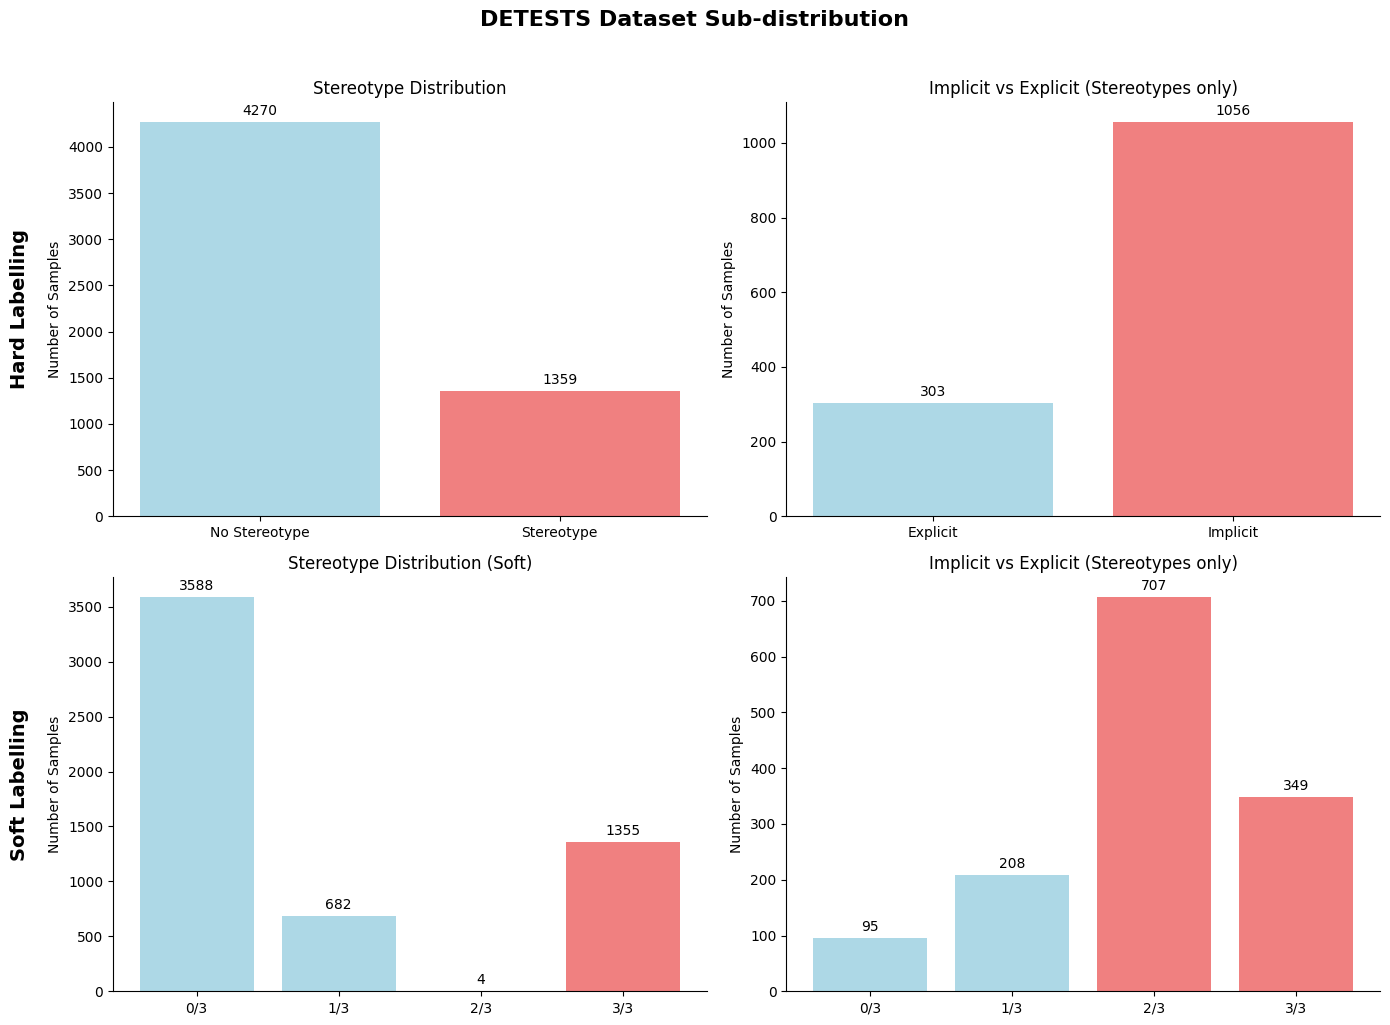

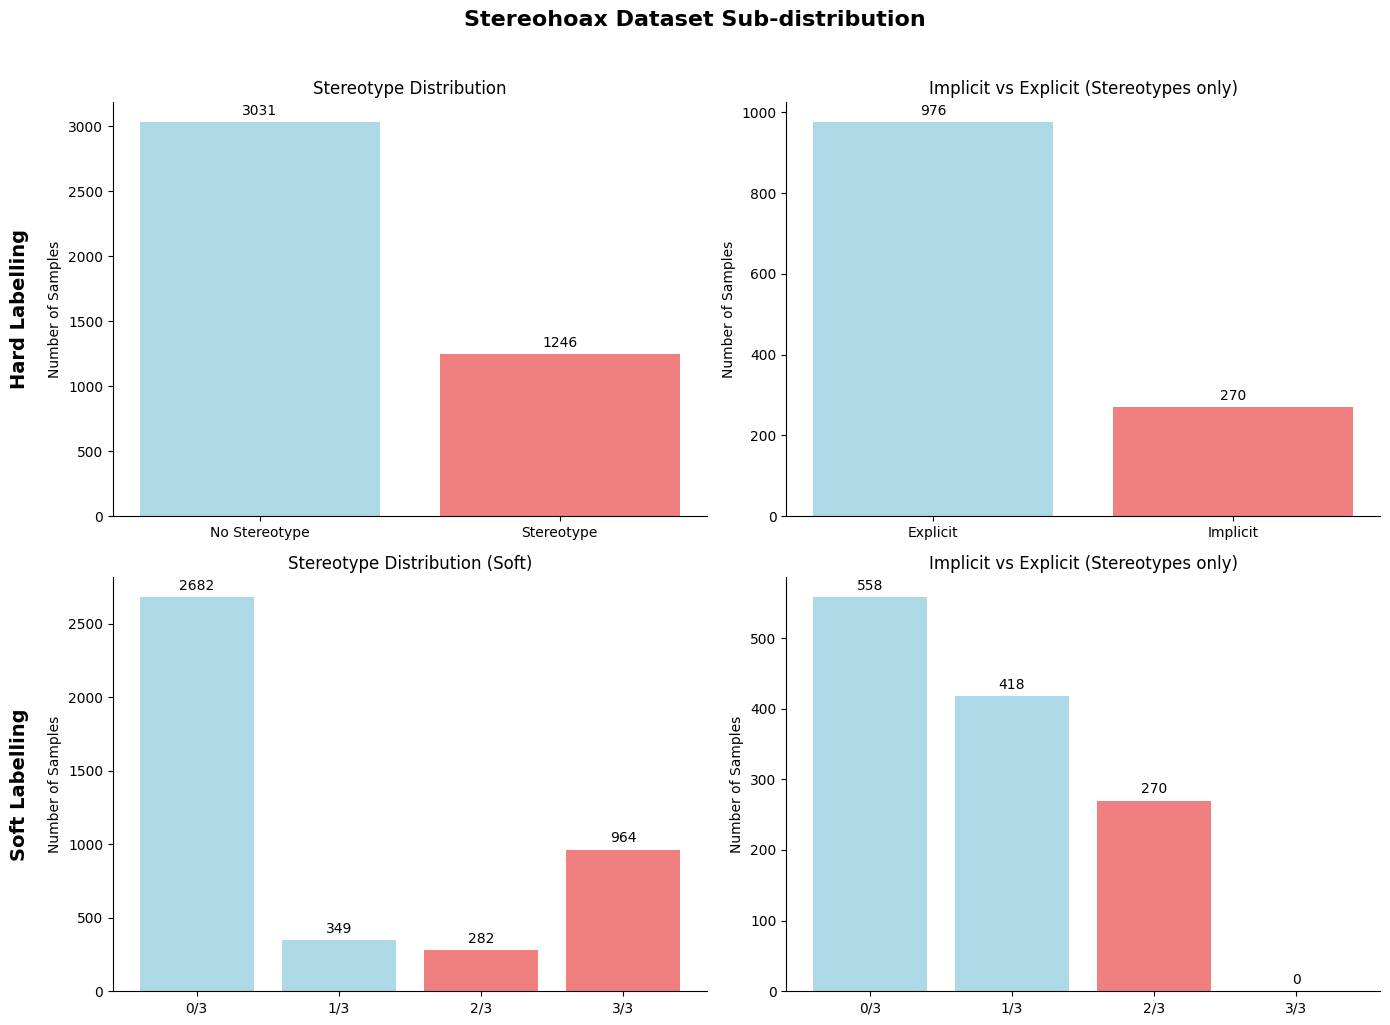

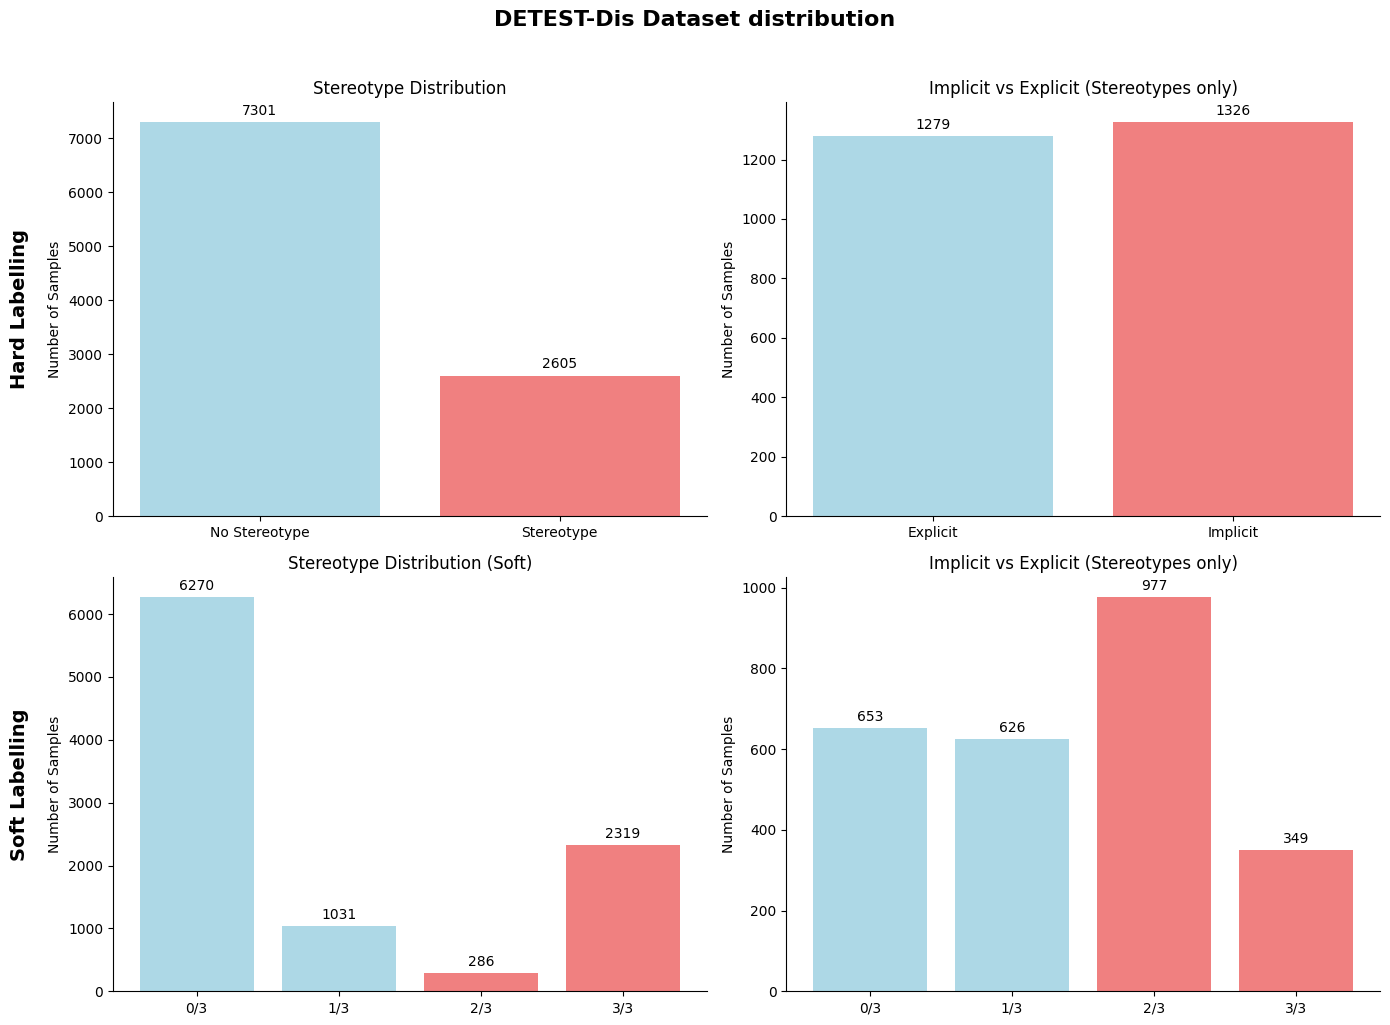

In [4]:
# 1. Apply to DETESTS source
detest_subset = detests_dataset_df.loc[detests_dataset_df["source"] == "detests"]
plot_detest_distribution(
    df=detest_subset, 
    title="DETESTS Dataset Sub-distribution", 
    save_name="detests_source_distribution.png"
)

# 2. Apply to Stereohoax source
stereohoax_subset = detests_dataset_df.loc[detests_dataset_df["source"] == "stereohoax"]
plot_detest_distribution(
    df=stereohoax_subset, 
    title="Stereohoax Dataset Sub-distribution", 
    save_name="stereohoax_source_distribution.png"
)

plot_detest_distribution(df=detests_dataset_df, title="DETEST-Dis Dataset distribution", save_name="detest_dis_distribution.png")

In [5]:
detests_dataset_df.columns

Index(['source', 'id', 'comment_id', 'text', 'level1', 'level2', 'level3',
       'level4', 'stereotype_a1', 'stereotype_a2', 'stereotype_a3',
       'stereotype', 'stereotype_soft', 'implicit_a1', 'implicit_a2',
       'implicit_a3', 'implicit', 'implicit_soft'],
      dtype='object')

In [6]:
detests_dataset_df_for_agreemet = detests_dataset_df.copy()

impl_cols = ["implicit_a1", "implicit_a2", "implicit_a3"]
ster_cols = ["stereotype_a1", "stereotype_a2", "stereotype_a3"]

# Usar el método mask condicionado a que los estereotipos sean == 0
detests_dataset_df_for_agreemet[impl_cols] = detests_dataset_df_for_agreemet[impl_cols].mask(
    detests_dataset_df_for_agreemet[ster_cols].values == 0
)

# EXIST

In [7]:
exists_dataset_training_df = pd.read_json("../data/EXIST2024_training.json", orient="index")
exists_dataset_training_df["labels_task1_soft"] = exists_dataset_training_df["labels_task1"].apply(lambda x: x.count("YES")/len(x))
exists_dataset_training_df["labels_task1_hard"] = exists_dataset_training_df["labels_task1"].apply(lambda x: 1 if x.count("YES") > 3 else 0 if x.count("YES") < 3 else 0.5)

In [8]:
from collections import Counter

def get_task3_hard_labels(row):
    # Count how many people voted YES on task 1
    num_yes = row["labels_task1"].count("YES")
    
    if num_yes == 0:
        return []

    # Flatten the lists of lists from all annotators, filtering out '-'
    all_votes = [label for annotator_labels in row["labels_task3"] for label in annotator_labels if label != '-']
    counts = Counter(all_votes)
    
    # Extract labels that have majority agreement among those who actually voted YES
    return [label for label, count in counts.items() if count > (num_yes / 2)]

def get_task3_soft_labels(row):
    # Count how many people voted YES on task 1
    num_yes = row["labels_task1"].count("YES")
    
    if num_yes == 0:
        return {}

    # Flatten the lists of lists from all annotators, filtering out '-'
    all_votes = [label for annotator_labels in row["labels_task3"] for label in annotator_labels if label != '-']
    counts = Counter(all_votes)
    # Calculate soft scores: votes / num_yes (so it's relative to those who voted yes)
    return {label: count / float(num_yes) for label, count in counts.items()}


# Apply to create a new column containing only the hard labels (list of labels)
exists_dataset_training_df["labels_task3_hard"] = exists_dataset_training_df.apply(get_task3_hard_labels, axis=1)

# Automatically create 0/1 columns for each unique hard label using pandas get_dummies
task3_dummies = exists_dataset_training_df["labels_task3_hard"].str.join('|').str.get_dummies()
task3_dummies.columns = [f"label_task3_{c}_hard" for c in task3_dummies.columns]

# Apply to compute soft labels (dictionary of category mapped to its fraction)
soft_labels_dicts = exists_dataset_training_df.apply(get_task3_soft_labels, axis=1)

# Expand the dictionaries into soft label columns (filling missing categories with 0.0)
task3_soft_df = pd.DataFrame(soft_labels_dicts.tolist(), index=exists_dataset_training_df.index).fillna(0.0)
task3_soft_df.columns = [f"label_task3_{c}_soft" for c in task3_soft_df.columns]

# Join back to dataset
exists_dataset_training_df = exists_dataset_training_df.join([task3_dummies, task3_soft_df])

# Display the first few rows showing the new columns
cols_to_show = ["labels_task3", "labels_task3_hard"] + list(task3_soft_df.columns)
exists_dataset_training_df[cols_to_show].head()

,labels_task3,labels_task3_hard,label_task3_OBJECTIFICATION_soft,label_task3_SEXUAL-VIOLENCE_soft,label_task3_STEREOTYPING-DOMINANCE_soft,label_task3_IDEOLOGICAL-INEQUALITY_soft,label_task3_MISOGYNY-NON-SEXUAL-VIOLENCE_soft,label_task3_UNKNOWN_soft
100001,"[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-VIOLENCE], [-], [STEREOTYPING-DOMINANCE], [SEXUAL-VIOLENCE], [IDEOLOGICAL-INEQUALITY, MISOGYNY-NON-SEXUAL-VIOLENCE]]",[],0.400000,0.400000,0.20,0.2,0.2,0.0
100002,"[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",[OBJECTIFICATION],1.000000,0.000000,0.00,0.0,0.0,0.0
100003,"[[-], [-], [-], [-], [-], [-]]",[],0.000000,0.000000,0.00,0.0,0.0,0.0
100004,"[[-], [-], [IDEOLOGICAL-INEQUALITY], [-], [IDEOLOGICAL-INEQUALITY], [IDEOLOGICAL-INEQUALITY, OBJECTIFICATION, SEXUAL-VIOLENCE]]",[IDEOLOGICAL-INEQUALITY],0.333333,0.333333,0.00,1.0,0.0,0.0
100005,"[[STEREOTYPING-DOMINANCE, OBJECTIFICATION], [-], [IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [-], [IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE], [STEREOTYPING-DOMINANCE, OBJECTIFICATION]]","[STEREOTYPING-DOMINANCE, OBJECTIFICATION]",0.750000,0.000000,0.75,0.5,0.0,0.0


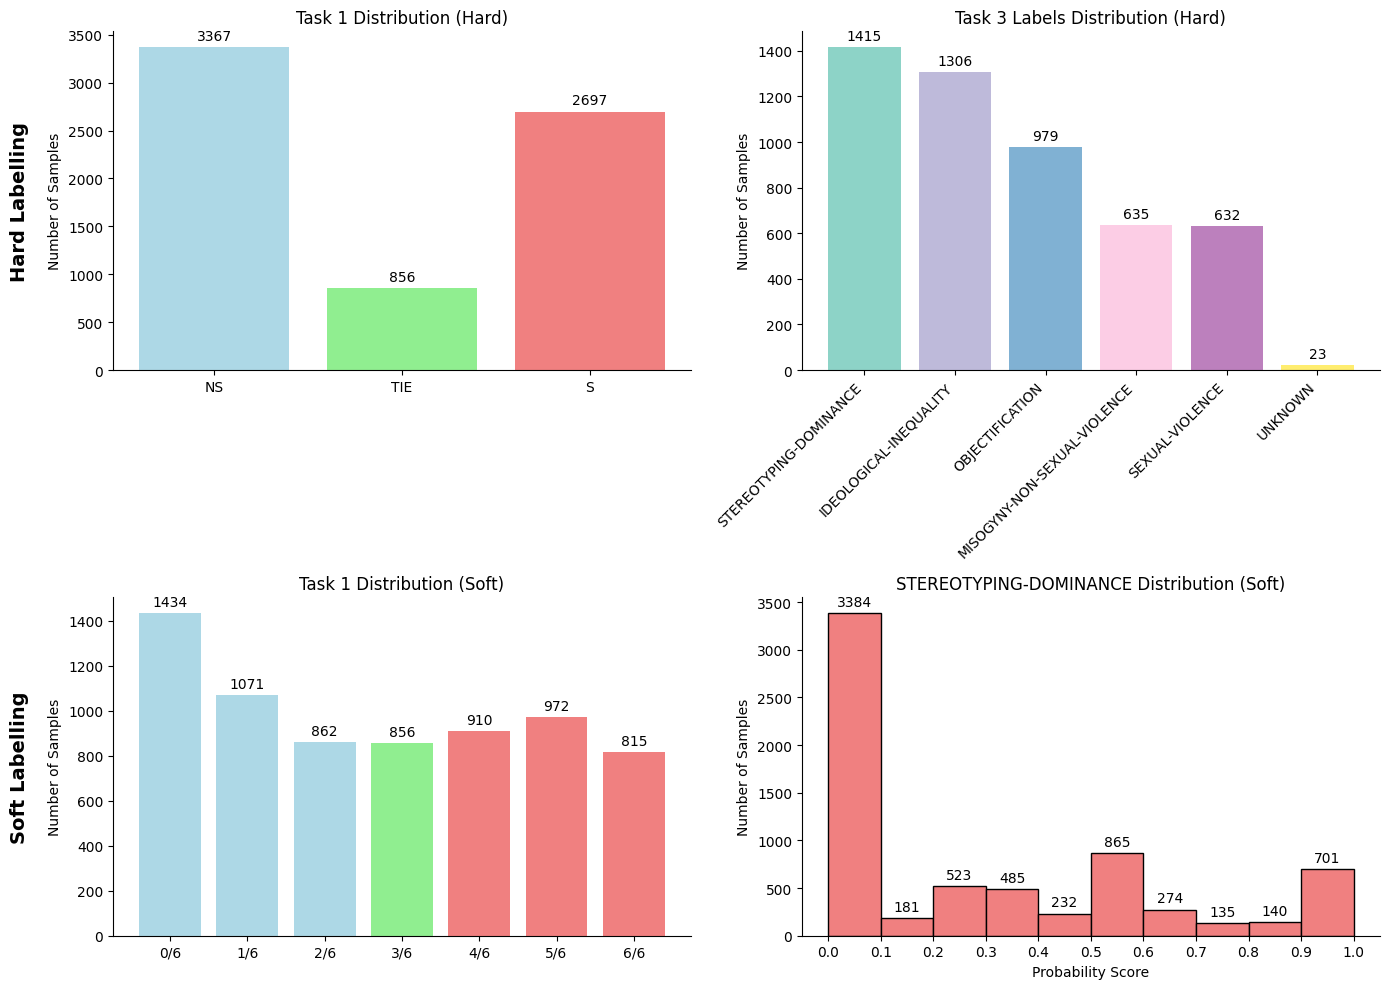

In [11]:
import os
import numpy as np

# Map Hard labels mapping 0 -> NM, 0.5 -> TIE, 1 -> M
# Using value_counts and reindexing to maintain strict order
exist_hard_dis = exists_dataset_training_df["labels_task1_hard"].map({0.0: "NS", 0.5: "TIE", 1.0: "S"}).value_counts()
exist_hard_dis = exist_hard_dis.reindex(["NS", "TIE", "S"]).fillna(0)

# Soft labels frequencies mapped to X/6 strings
# Since len(x) seems to be 6, multiplying by 6 gives the exact count of YES
exist_soft_counts = (exists_dataset_training_df["labels_task1_soft"] * 6).round().astype(int).value_counts()
exist_soft_labels = [f"{i}/6" for i in range(7)]
exist_soft_dis = exist_soft_counts.reindex(range(7)).fillna(0)
exist_soft_dis.index = exist_soft_labels

# Task 3 hard label counts
task3_cols = [col for col in exists_dataset_training_df.columns if col.startswith("label_task3_") and col.endswith("_hard")]
exist_task3_dis = exists_dataset_training_df[task3_cols].sum().sort_values(ascending=False)
# Strip "label_task3_" and "_hard" for the plot labels
exist_task3_dis.index = exist_task3_dis.index.str.replace("label_task3_", "").str.replace("_hard", "")

# Plotting on a 2x2 grid
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# --- ROW 1: Hard Labelling ---

# Colors: NM (light blue), TIE (light green), M (light coral)
hard_colors = ['lightblue', 'lightgreen', 'lightcoral']

bars1 = ax[0][0].bar(
    exist_hard_dis.index, 
    exist_hard_dis.values,
    color=hard_colors
)
ax[0][0].set_title('Task 1 Distribution (Hard)')
ax[0][0].set_ylabel('Number of Samples')
ax[0][0].bar_label(bars1, padding=3)

# Plot Task 3 counts on the first row and second column with distinct colors per bar
# Generates a gradient or set of distinct colours
task3_colors = plt.cm.Set3(np.linspace(0, 1, len(exist_task3_dis)))

bars2 = ax[0][1].bar(
    exist_task3_dis.index, 
    exist_task3_dis.values,
    color=task3_colors
)
ax[0][1].set_title('Task 3 Labels Distribution (Hard)')
ax[0][1].set_ylabel('Number of Samples')
ax[0][1].tick_params(axis='x', rotation=45)
# Ensure rotated labels align nicely
for label in ax[0][1].get_xticklabels():
    label.set_ha('right')
ax[0][1].bar_label(bars2, padding=3)

# Add Row 1 Title on the left side
ax[0][0].annotate('Hard Labelling', xy=(0, 0.5), xytext=(-ax[0][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[0][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')


# --- ROW 2: Soft Labelling ---

# Colors: [0/6..2/6] = lightblue, [3/6] = lightgreen, [4/6..6/6] = lightcoral
soft_colors = ['lightblue', 'lightblue', 'lightblue', 'lightgreen', 'lightcoral', 'lightcoral', 'lightcoral']

bars3 = ax[1][0].bar(
    exist_soft_dis.index, 
    exist_soft_dis.values,
    color=soft_colors
)
ax[1][0].set_title('Task 1 Distribution (Soft)')
ax[1][0].set_ylabel('Number of Samples')
ax[1][0].bar_label(bars3, padding=3)

# Task 3 specific Stereotyping dominance softly annotated distribution
# A histogram is more appropriate for continuous/semi-continuous soft probability distribution
st_dom_soft_col = "label_task3_STEREOTYPING-DOMINANCE_soft"
if st_dom_soft_col in exists_dataset_training_df.columns:
    counts, bins, patches = ax[1][1].hist(
        exists_dataset_training_df[st_dom_soft_col], 
        bins=np.arange(0, 1.1, 0.1), 
        color='lightcoral', 
        edgecolor='black'
    )
    ax[1][1].set_title('STEREOTYPING-DOMINANCE Distribution (Soft)')
    ax[1][1].set_ylabel('Number of Samples')
    ax[1][1].set_xlabel('Probability Score')
    ax[1][1].set_xticks(np.arange(0, 1.1, 0.1))
    ax[1][1].bar_label(patches, padding=3)
else:
    ax[1][1].text(0.5, 0.5, 'Data not found', horizontalalignment='center', verticalalignment='center')

# Add Row 2 Title on the left side
ax[1][0].annotate('Soft Labelling', xy=(0, 0.5), xytext=(-ax[1][0].yaxis.labelpad - 10, 0),
                  xycoords=ax[1][0].yaxis.label, textcoords='offset points',
                  size=14, ha='right', va='center', rotation=90, fontweight='bold')

# Clean up axes for presentations (remove top and right borders)
for axis in [ax[0][0], ax[0][1], ax[1][0], ax[1][1]]:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

# Create directory if missing and save figure
fig.savefig("../figures/exist_distributions.png", dpi=300, transparent=True, bbox_inches='tight')

plt.show()

In [20]:
exists_dataset_training_df.loc[(exists_dataset_training_df["labels_task1_hard"] == 1.0) & (exists_dataset_training_df["lang"] == "en"), ["tweet", "label_task3_STEREOTYPING-DOMINANCE_hard", "label_task3_STEREOTYPING-DOMINANCE_soft"]].head(40)

,tweet,label_task3_STEREOTYPING-DOMINANCE_hard,label_task3_STEREOTYPING-DOMINANCE_soft
200002,"Writing a uni essay in my local pub with a coffee. Random old man keeps asking me drunk questions when I'm trying to concentrate &amp; ends with ""good luck, but you'll just end up getting married and not use it anyway"". #EverydaySexism is alive and well 🙃",1,0.800000
200003,@UniversalORL it is 2021 not 1921. I dont appreciate that on two rides by myself your team member looked behind me and asked the man behind how many in my party. Not impressed #everydaysexism,0,0.500000
200006,"According to a customer I have plenty of time to go spent the Stirling coins he wants to pay me with, in Derry. ""Just like any other woman, I'm sure of it."" #EveryDaySexism in retail.",0,0.500000
200007,"So only 'blokes' drink beer? Sorry, but if you aren't a 'bloke' you drink wine apparently....... #EverydaySexism alive and well in @HayesAmbleside @MelissaCole @Shinybiscuit https://t.co/AP4GeusmOX",1,0.833333
200011,"#EverydaySexism means women usually end up in lower paid support work; when that starts to change, traditionalists notice unfairness that previously hasn't bothered them at all. https://t.co/YOLJ9V8E6Z",1,0.666667
200013,"@orlamuldoon @NWCI @IrishRunnerMag @ReclaimTS @EverydaySexism @SAFEIreland @Womens_Aid Hi Orla. Interesting piece. On No 2. As a policy response, do you believe early-in-life prosecution and punishment is the way to go with boys, young men when they offend against girls and women? Is this how you see by a zero tolerance approach being instituted?",0,0.000000
200015,@MarkPaulTimes @colettebrowne #EveryDaySexism Dear God.Colette is capable of identifying sexism literally anywhere.Good to see @SocDems developing their own female Grandpa Simpson https://t.co/7bEDkdsDX4,0,0.000000
200016,@RMatthewsPsyEdu @ITV @jamesmartinchef @EverydaySexism @CCriadoPerez @ginarippon1 The women will all be at home cooking for the family,1,0.666667
200017,@Geek_Pride @kathrynstimpson @medicalpoke @EverydaySexism Wouldn't work for women who get assaulted at home or work. Also would give the government the ability to track anyone for any reason.,0,0.250000
200018,"February 28, 2022: Daily Mail website voyeuristically describes 2 people as ""flaunting"" &amp; 29 as ""showing off"". #dailymail #everydaysexism #misogyny",0,0.500000


In [19]:
exists_dataset_training_df.columns

Index(['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators',
       'gender_annotators', 'age_annotators', 'ethnicities_annotators',
       'study_levels_annotators', 'countries_annotators', 'labels_task1',
       'labels_task2', 'labels_task3', 'split', 'labels_task1_soft',
       'labels_task1_hard', 'labels_task3_hard',
       'label_task3_IDEOLOGICAL-INEQUALITY_hard',
       'label_task3_MISOGYNY-NON-SEXUAL-VIOLENCE_hard',
       'label_task3_OBJECTIFICATION_hard', 'label_task3_SEXUAL-VIOLENCE_hard',
       'label_task3_STEREOTYPING-DOMINANCE_hard', 'label_task3_UNKNOWN_hard',
       'label_task3_OBJECTIFICATION_soft', 'label_task3_SEXUAL-VIOLENCE_soft',
       'label_task3_STEREOTYPING-DOMINANCE_soft',
       'label_task3_IDEOLOGICAL-INEQUALITY_soft',
       'label_task3_MISOGYNY-NON-SEXUAL-VIOLENCE_soft',
       'label_task3_UNKNOWN_soft'],
      dtype='object')

In [22]:
exist_2022_df = pd.read_csv("../data/EXIST2021_training.tsv", sep="\t")

In [24]:
exist_2022_df["task2"].value_counts()

task2
non-sexist                      3600
ideological-inequality           866
stereotyping-dominance           809
misogyny-non-sexual-violence     685
sexual-violence                  517
objectification                  500
Name: count, dtype: int64

In [33]:
exist_2022_df.loc[(exist_2022_df["language"] == "en") & (exist_2022_df["task1"] == "non-sexist")].head(20)

,test_case,id,source,language,text,task1,task2
1,EXIST2021,2,twitter,en,"Now, back to these women, the brave and the beautiful, @Clare_Crawley and @tayshia. These bad ass babes, are deserve so much credit for how this season has gone. As a woman, I’ve learned so much from them and feel more empowered to expect more in future relationships.",non-sexist,non-sexist
3,EXIST2021,4,twitter,en,@AurelieGuiboud Incredible! Beautiful!But I laughed so much when I read about you drifting in your wheelchair.I can just picture it https://t.co/uvl5HhbmbR,non-sexist,non-sexist
4,EXIST2021,5,twitter,en,"i find it extremely hard to believe that kelly or a 66 yr old mum would believe any of this, so it makes me question what the fuck their game was? especially as none of them have apologised or tried to explain? &amp; their immediate response was to like tweets attacking the victims",non-sexist,non-sexist
6,EXIST2021,7,twitter,en,"@Texas17761 @MomsDemand True story: Me to 18 y/o daughter: Get a gun so you can shoot any would-be rapist.18: That's sexist and victim blaming. Women shouldn't need to carry guns to protect themselves.Me: You're right, they shouldn't have to. Some people are evil and you need to deal with them.",non-sexist,non-sexist
7,EXIST2021,8,twitter,en,Head coach Caroline Ouellette is excited to share some great news about the Stingers' #GivingTuesday initiative. An anonymous donor has offered to match gifts to the Concordia women's hockey team up to a total of $5K.https://t.co/JH9gWbVl2z#CUstingers #CUhockey #USPORTS https://t.co/6En6mxoI0i,non-sexist,non-sexist
8,EXIST2021,9,twitter,en,"@BankofIndia_IN Devli Branch , New Delhi should be avoided by all and deserves being shut because the employees therein are least bothered with the consumer’s woes! 20 days yet no redressal of woes! #disappointed #harassed",non-sexist,non-sexist
9,EXIST2021,10,twitter,en,"Bravo to this woman. No matter what you believe about #Covid, standing up for your beliefs when everyone around you is making you feel crazy is hard to do. She held her own. If you know this woman, please tag her. I need to send her a bottle of wine or something. https://t.co/LVNKnFzc3v",non-sexist,non-sexist
11,EXIST2021,12,twitter,en,"let me just say a quick thankyou to Hezekiah’s mom for this pound of chocolate. hezekiah actually drives me crazy at work, but as a 5 year old I have to forgive him and be nice",non-sexist,non-sexist
12,EXIST2021,13,twitter,en,@DIZZYISPOG not the victim card-,non-sexist,non-sexist
13,EXIST2021,14,twitter,en,@DazzlingDonny @FtblBean That's because us and Sunderland fans are too busy being dickheads to our shitshow managers and owners to slag off other clubs,non-sexist,non-sexist
